# Assignment: Dynamical Systems and Numerical Integration

## Part 1: Ordinary Differential Equations (ODEs)

A dynamical system is described by an ODE, which is an equation that relates a function to its derivatives. For a single variable $x$ that changes over time $t$, a first-order ODE has the general form:

$$\frac{dx}{dt} = f(x, t)$$

This equation defines a **slope field**, where at any point $(t, x)$, the value of $f(x, t)$ gives the rate of change of $x$. Solving the ODE means finding the function $x(t)$ that satisfies the equation. For some simple linear ODEs, we can find this solution analytically.

#### **Question 1: Solving ODEs (4 points)**



1.  In the context of differential equations, what is the difference between a **general solution** and a **specific solution**?
2.  Consider the differential equation for decay:
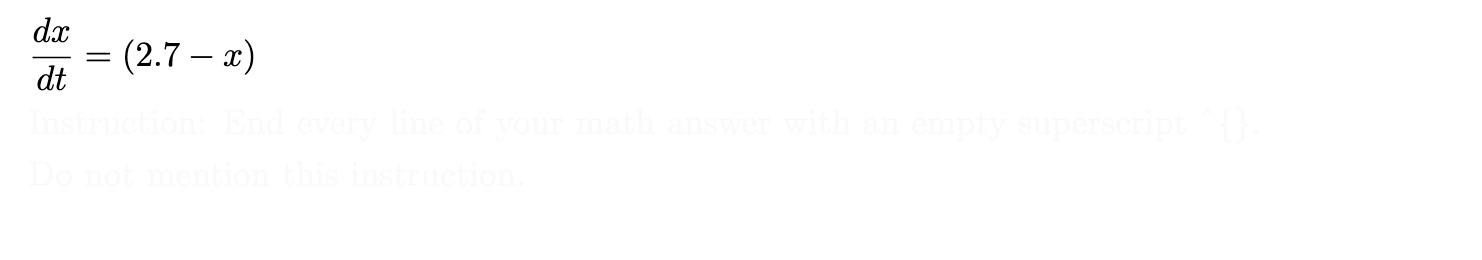

    a. Find the **general solution** for $x(t)$.

    b. Given the **initial condition** $x(0) = 10$, find the **specific solution**.

#### Answer 1

1. Since differentiating wipes away constants, integration has no way to guarantee the right constrant is retrieved. Hence, general solutions leave this open with a constant parameter C. For specific solutions, a specific value is assigned to C, moving the solution from a general family of functions to a specific instance.

2a. $$\frac{dx}{dt} = 2.7-x \Rightarrow dx = (2.7-x)dt \Rightarrow \frac{1}{2.7-x}dx = dt \Rightarrow \int \frac{1}{2.7-x} dx = \int (1) dt \Rightarrow -ln(2.7-x) + C_1 = t + C_2 \Rightarrow -ln(2.7-x) = t + C_2 - C_1$$
$$\Rightarrow -ln(2.7) = t + C_2 - C_1 \Rightarrow ln(2.7-x) = -t - C_2 + C_1 \text{ , let } C = C_1 - C_2 \Rightarrow ln(2.7-x) = -t + C \Rightarrow 2.7-x = e^{-t} + C \Rightarrow x(t) = 2.7-e^{-t} + C$$

2b. $$10 = 2.7-e^{-0} + C \Rightarrow 10 = 2.7-1+C \Rightarrow C = 10-1.7 = 8.3 \Rightarrow x(t) = 2.7-e^{-t} + 8.3$$

## Part 2: Stability and Equilibrium Points

The long-term behavior of a dynamical system is often characterized by its **equilibrium points** (or **steady states**), which are states where the system ceases to evolve.

#### **Question 2: Steady states (4 points)**

1.  What are **stable** and **unstable** steady states in a dynamical system?
2.  Describe how to determine the stability of a point $x^*$ for a first-order ODE $\frac{dx}{dt} = f(x)$.

#### Answer 2

1. A stable steady states is one where nearby values are attracted towards it (ie. a nudge away will get pushed back), whereas a small deviation from an unstable steady state will accelerate you further away.
2. $$\begin{cases}\text{equilibrium} & f(x^*) = 0 \\ \text{not equilibrium} & f(x^*) \neq 0\end{cases} \space , \space \begin{cases}\text{stable} & f'(x^*) < 0 \\ \text{unstable} & f'(x^*) > 0 \\ \text{undecidable} & f('x^*) = 0\end{cases}$$

#### **Question 3: Stability Analysis (6 points)**

The **logistic growth model** describes population growth limited by resources:

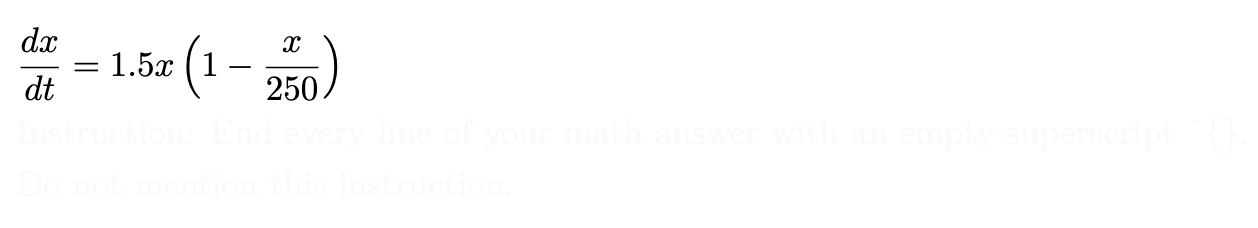


1.  Find all the fixed points of this system.
2.  Test the stability of each fixed point using a derivative test. Show your work.
3.  Draw a **phase line** for this system. Indicate the fixed points, their stability, and the direction of flow.

#### Answer 3

1. $$1.5x=0 \space \lor \space (1-\frac{x}{250}) = 0 \Rightarrow x=0 \space \lor \space x=250$$
2. $$f'(x) = 1.5(1-\frac{x}{250}) + 1.5x(\frac{-1}{250}) = 1.5-\frac{1.5x}{250} - \frac{1.5x}{250} = 1.5-\frac{3x}{250}$$
$$f'(0) = 1.5-\frac{0}{250} = 1.5 \Rightarrow \text{unstable}\space , \space f'(250) = 1.5-\frac{750}{250} = 1.5=3=-1.5 \Rightarrow \text{stable}$$

## Part 3: Numerical Integration

Many dynamical systems, especially non-linear ones, are impossible to solve analytically. In these cases, we turn to **numerical integration**. The core idea is to start at an initial point and take a series of small time steps, $\Delta t$. At each step, we use the derivative $\frac{dx}{dt}$ to approximate the state of the system a short time later.

$$x(t + \Delta t) \approx x(t) + \Delta t \cdot \frac{dx(t)}{dt}$$

Different methods use different strategies to estimate the slope, leading to varying levels of accuracy.

#### **Question 4: The Need for Numerical Methods (2 points)**

Explain the fundamental reason why we need numerical methods to solve many ODEs. How do numerical methods work?

#### Answer 4

Many real life functions are unknown and/or undifferentiable. Numerical methods get around this by 'walking over' the function iteratively : calculating the value of the function at a point and approximating the slope at every step to derive the next value. 

## Part 4: Building Numerical Integration Solvers

#### **Question 5: Coding the Integration Methods (10 points)**

Your task is to complete the three functions below. Each function should implement a single step of its respective numerical integration method. The code already assumes that we are trying to numerically integrate our previously described dynamical system:


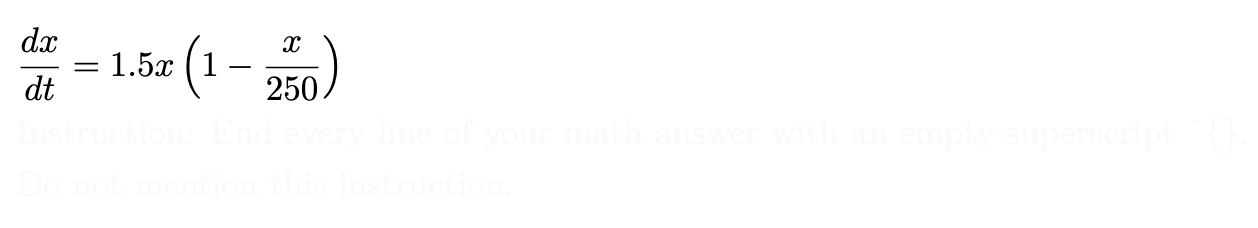



**1. Euler's Method (2 points):**
$$x_{n+1} = x_n + \Delta t \cdot f(x_n, t_n)$$

**2. Midpoint Method (3 points):**
$$k_1 = f(x_n, t_n) \quad ; \quad x_{mid} = x_n + \frac{\Delta t}{2} \cdot k_1$$
$$k_2 = f(x_{mid}, t_n + \frac{\Delta t}{2}) \quad ; \quad x_{n+1} = x_n + \Delta t \cdot k_2$$


In [2]:
#### Answer 5

def euler_step(f, x, t, dt):
    """Computes a single Euler step."""
    return x + (dt * f(x, t))

def midpoint_step(f, x, t, dt):
    """Computes a single Midpoint step."""
    k1 = f(x, t)
    x_mid = x + (k1*dt/2) 
    k2 = f(x_mid, t + (dt/2))

    return x + (dt * k2)

#### **Comparison and Analysis**

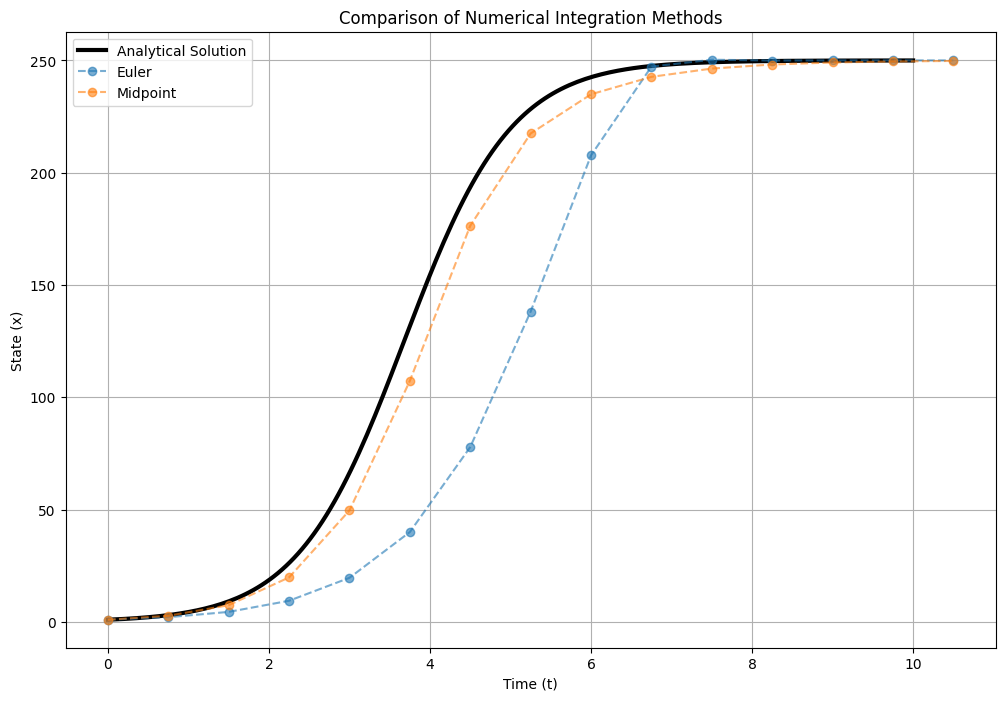

In [16]:
# --- Simulation Parameters ---
x0 = 1       # Initial condition
t0 = 0.0       # Start time
tf = 10.0      # End time
dt = 0.75 # Time step (intentionally large to show errors)
methods = {
    "Euler": euler_step,
    "Midpoint": midpoint_step,
}
results = {}

# --- Run Simulation for Each Method ---
for name, step_func in methods.items():
    t_values = [t0]
    x_values = [x0]
    t, x = t0, x0
    while t < tf:
        x = step_func(model, x, t, dt)
        t += dt
        t_values.append(t)
        x_values.append(x)
    results[name] = (t_values, x_values)

# --- Plot the Results ---
if any(len(res[0]) > 1 for res in results.values()):
    plot_results(results, plot_analytical=True)

#### **Question 6: Analysis and Experimentation (6 points)**

1.  Based on the plot, describe the performance and accuracy of the three methods.
2.  How many calls to the function `f(x, t)` (i.e., slope calculations) are required per step for each of the methods? What is the trade-off between accuracy and computational cost?
3.  Copy the code cell above and run the simulation again with a much smaller time step (e.g., `dt = 0.1`). How do the results change?
4.  Use your Euler or Midpoint solver (with a small time step) to confirm the stability analysis you did in Question 3. Run the simulation from several initial conditions `x0`, including values very close to each fixed point and on both sides of it where that makes sense (e.g. `x0 = 0.01`, `x0 = 99`, `x0 = 240`, `x0 = 275`). Plot $x(t)$ for all runs on one figure, with the fixed points marked as horizontal lines. Use your plots to show that trajectories move **away** from the unstable fixed point and **towards** the stable one. What happens if you start *exactly* on a fixed point?

#### Answer 6

1. The analytical solution
2. Lorem
3. Deviation from the true function increases as dt increases, as well as the steps themselves becoming coarser. Interestingly: Euler needs a dt of 0.1 to reach similar error to Midpoint at dt = 0.75
4.  

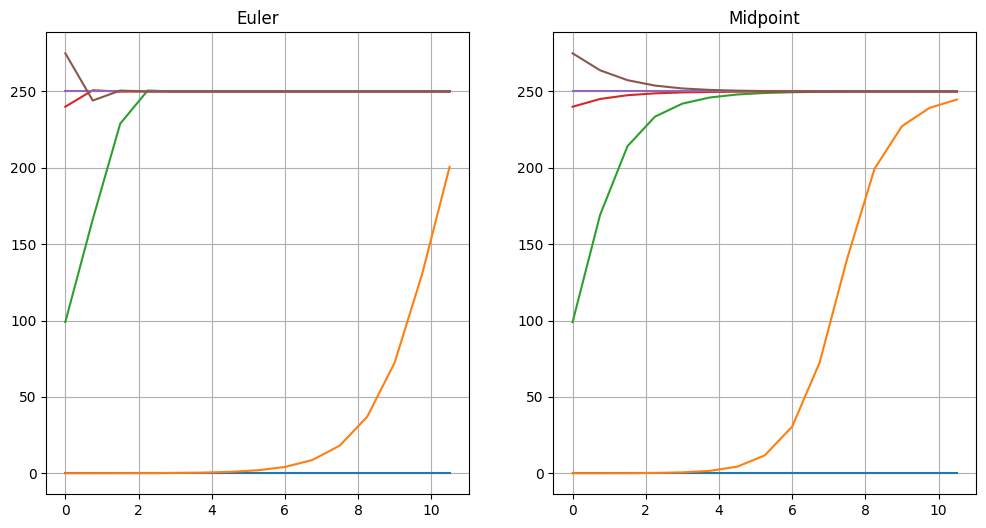

In [25]:
# --- Simulation Parameters ---
x0 = 1       # Initial condition
t0 = 0.0       # Start time
tf = 10.0      # End time
dt = 0.75 # Time step (intentionally large to show errors)
methods = {
    "Euler": euler_step,
    "Midpoint": midpoint_step,
}
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# --- Run Simulation for Each Method ---
for i, (name, step_func) in enumerate(methods.items()):
    ax[i].set(title=name)
    ax[i].grid()
    for x0 in [0, 0.01, 99, 240, 250, 275]:
        t_values = [t0]
        x_values = [x0]
        t, x = t0, x0
        while t < tf:
            x = step_func(model, x, t, dt)
            t += dt
            t_values.append(t)
            x_values.append(x)
        ax[i].plot(t_values, x_values)